# ⚡ TurboPredict — Modelo de Crédito ML
**Challenge FIAP 2026 · Equipe 3GCM · Sprint 3 MVP**

Pipeline: Split Temporal → EDA (só treino) → Feature Engineering → Baseline → XGBoost Regressor → SHAP → Exportação

| Item | Detalhe |
|---|---|
| **Granularidade** | Por beneficiário (cedente/CNPJ) |
| **Targets** | `pd_30`, `pd_60`, `pd_90` — proporção contínua de boletos em atraso [0,1] |
| **Tipo de modelo** | Regressão (XGBRegressor) — preserva granularidade da probabilidade |
| **Split temporal** | 80% beneficiários mais antigos → treino · 20% mais recentes → validação |
| **Métricas** | RMSE, MAE, R², Spearman |
| **Dados** | `base_boletos_fiap.csv` + `base_auxiliar_fiap.csv` (Núclea) |

## 0. Instalação de dependências

In [47]:
!pip install xgboost shap scikit-learn pandas numpy matplotlib seaborn joblib scipy --quiet


[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Imports e configurações

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import json
import shap
from pathlib import Path
from scipy import stats

from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.4f}'.format)
plt.style.use('dark_background')

C = {'risco': '#ef5350', 'neutro': '#4fc3f7', 'ok': '#66bb6a',
     'warn': '#ffc107', 'bg': '#0d1b35', 'grid': '#1e3a5f'}

DATA_DIR  = Path('data')
MODEL_DIR = Path('models')
MODEL_DIR.mkdir(exist_ok=True)

TARGETS = ['pd_30', 'pd_60', 'pd_90']
CORES_TARGET = {'pd_30': C['warn'], 'pd_60': C['risco'], 'pd_90': '#ab47bc'}

print('Imports OK')

Imports OK


## 2. Carregamento dos dados

In [117]:
df_bol = pd.read_csv(
    DATA_DIR / 'base_boletos_fiap.csv',
    parse_dates=['dt_emissao', 'dt_vencimento', 'dt_pagamento']
)

df_aux = pd.read_csv(DATA_DIR / 'base_auxiliar_fiap.csv')

print(f'Boletos : {df_bol.shape[0]:,} x {df_bol.shape[1]}')
print(f'Auxiliar: {df_aux.shape[0]:,} x {df_aux.shape[1]}')
print(f'Periodo : {df_bol.dt_emissao.min().date()} -> {df_bol.dt_emissao.max().date()}')
print(f'Beneficiarios unicos: {df_bol.id_beneficiario.nunique():,}')
df_bol.head(3)

Boletos : 7,118 x 10
Auxiliar: 4,612 x 11
Periodo : 2019-08-16 -> 2024-05-31
Beneficiarios unicos: 1,189


,id_boleto,id_pagador,id_beneficiario,dt_emissao,dt_vencimento,dt_pagamento,vlr_nominal,vlr_baixa,tipo_baixa,tipo_especie
0,00c6dec1b869d310010c8e3741262d7e96b0a622a7cf40...,24037765228ca1bce6743570728395541ca481ac79d854...,cf98a6d61719ae21047ea999c57051ffcae0809677068f...,2024-03-27,2024-05-09,2024-03-29,2714.6600,NaN,5 - Baixa integral por solicitacao do cedente,DM DUPLICATA MERCANTIL
1,6548008e566d8f6696c5561a845248f61bfd2e3891711c...,24037765228ca1bce6743570728395541ca481ac79d854...,a711fb1183bc159fdcb672d61f9e052cda50f9e0a76e68...,2024-03-13,2024-05-05,2024-05-06,5522.6300,5522.6300,1 - Baixa integral intrabancaria,DMI DUPLICATA MERCANTIL INDICACAO
2,7409b9a978ccf059c68841c2317a3196adfd8d405854fa...,1c63664185066fb412e0803d751efbde86444efd8c265f...,8b4a7a67986a724fbc3ea10174aef547975c3d7257a3b1...,2024-05-17,2024-05-30,2024-05-27,3338.3000,3338.3000,0 - Baixa integral interbancaria,DM DUPLICATA MERCANTIL


## 3. Split Temporal — Treino / Validação

**Feito ANTES da EDA** para evitar data leakage: toda análise exploratória usa exclusivamente os dados de treino.


In [118]:
# Calcular DPD e flags — necessário para definir targets
df_bol['dpd']                  = (df_bol['dt_pagamento'] - df_bol['dt_vencimento']).dt.days
df_bol['dpd']                  = df_bol['dpd'].fillna(999)  # nao pagos -> 999
df_bol['em_atraso']            = df_bol['dpd'] > 0
df_bol['atraso_30']            = df_bol['dpd'] >= 30
df_bol['atraso_60']            = df_bol['dpd'] >= 60
df_bol['atraso_90']            = df_bol['dpd'] >= 90
df_bol['mes_emissao']          = df_bol['dt_emissao'].dt.to_period('M')
df_bol['pct_baixa_vs_nominal'] = (df_bol['vlr_baixa'] / df_bol['vlr_nominal']).clip(0, 1)
df_bol['mes_ref'] = df_bol['dt_emissao'].dt.to_period('M').dt.to_timestamp()

# deixar dois últimos meses para validação, e os anteriores para treino
df_bol_train = df_bol[df_bol['dt_emissao'] < '2024-04-01'].copy()
df_bol_valid_0 = df_bol[df_bol['dt_emissao'] >= '2024-04-01'].copy()

print(f'Boletos treino          : {len(df_bol_train):,}')
print(f'Boletos validacao       : {len(df_bol_valid_0):,}')
print(f"Beneficiários únicos treino          : {len(df_bol_train['id_beneficiario'].unique())}")
print(f"Beneficiários únicos teste          : {len(df_bol_valid_0['id_beneficiario'].unique())}")


Boletos treino          : 3,518
Boletos validacao       : 3,600
Beneficiários únicos treino          : 628
Beneficiários únicos teste          : 802


In [53]:
ids_train = set(df_bol_train['id_beneficiario'].unique())
ids_valid  = set(df_bol_valid_0['id_beneficiario'].unique())

print('Só no treino (sem boletos recentes):', len(ids_train - ids_valid))
print('Só no teste (clientes novos)        :', len(ids_valid - ids_train))
print('Em ambos (clientes com histórico)   :', len(ids_train & ids_valid))

Só no treino (sem boletos recentes): 387
Só no teste (clientes novos)        : 561
Em ambos (clientes com histórico)   : 241


Podemos perceber que uma quantidade grande dos beneficiários só aparece na base de teste - ou seja, são beneficiários novos, sem histórico de pagamento que possa ser usado no treinamento do modelo. Não é viável avaliar a performance do modelo nesses com eles, já que podem ter um comportamento de pagamento consideravelmente diferente dos beneficiários com histórico. 

Por isso, vamos treinar o modelo com os 387 (sem boletos recentes) + 241 (com histórico) beneficiários no período < abril/2024, e testá-lo nos 241 no período de abril e maio/2024.

In [19]:
ids_aval = ids_train & ids_valid
df_bol_valid = df_bol_valid_0[df_bol_valid_0['id_beneficiario'].isin(ids_aval)]

## 4. EDA — Análise Exploratória

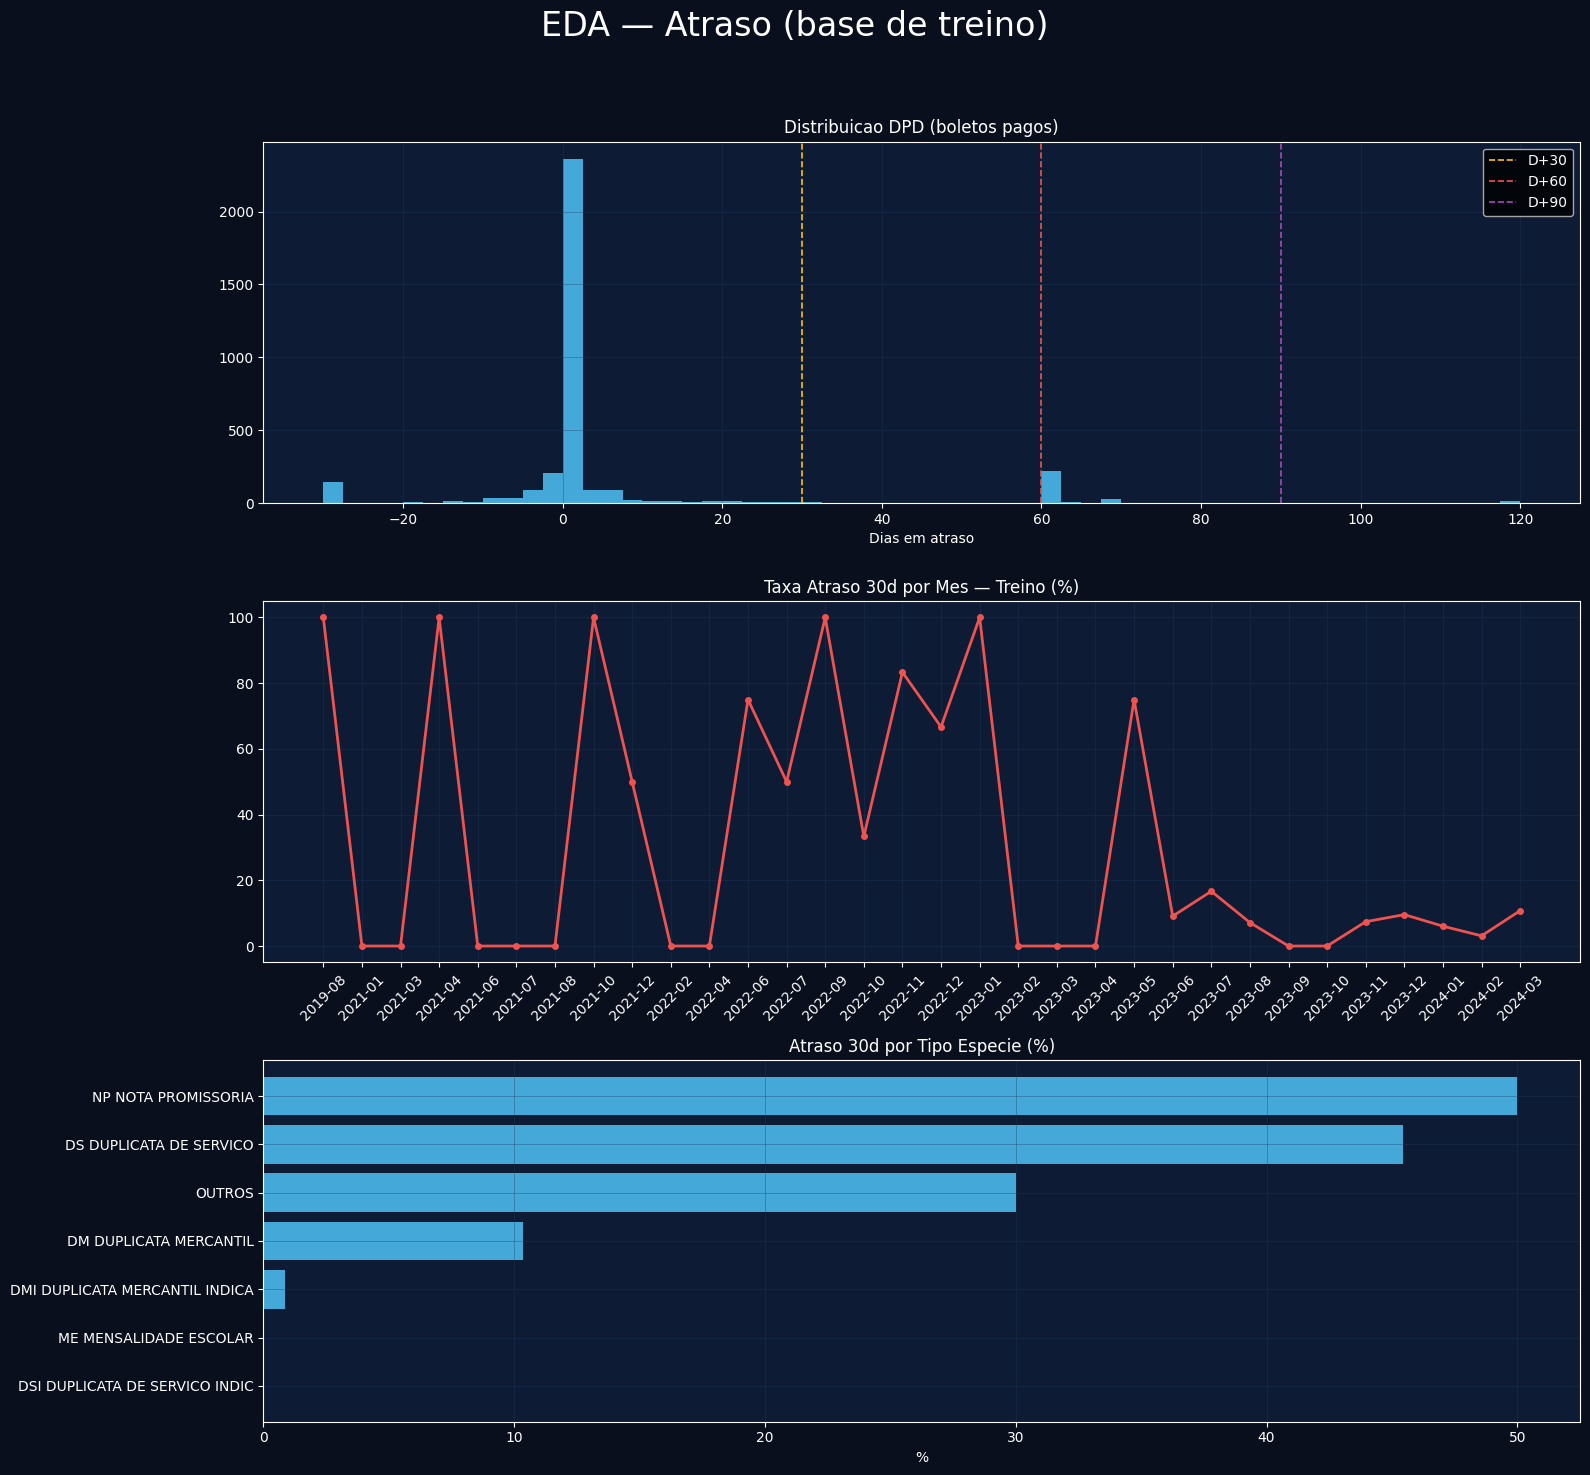

Boletos nao pagos (treino): 20
Taxa atraso 30d: 8.9%
Taxa atraso 60d: 8.4%
Taxa atraso 90d: 1.1%


In [54]:
dpd_pago = df_bol_train[df_bol_train['dpd'] < 999]['dpd']

fig, axes = plt.subplots(nrows= 3, ncols= 1, figsize=(16, 15), facecolor='#0a0f1e')
fig.suptitle('EDA — Atraso (base de treino)\n\n', color='white', fontsize=24)

axes[0].hist(dpd_pago.clip(-30, 120), bins=60, color=C['neutro'], alpha=0.85)
for d, cor in [(30, C['warn']), (60, C['risco']), (90, '#ab47bc')]:
    axes[0].axvline(d, color=cor, linestyle='--', linewidth=1.2, label=f'D+{d}')
axes[0].set_title('Distribuicao DPD (boletos pagos)', color='white')
axes[0].set_xlabel('Dias em atraso'); axes[0].legend()

ts = df_bol_train.groupby('mes_emissao')['atraso_30'].mean() * 100
axes[1].plot(ts.index.astype(str), ts.values, color=C['risco'], linewidth=2, marker='o', markersize=4)
axes[1].set_title('Taxa Atraso 30d por Mes — Treino (%)', color='white')
axes[1].tick_params(axis='x', rotation=45)

esp = df_bol_train.groupby('tipo_especie')['atraso_30'].mean().sort_values(ascending=True)
axes[2].barh(esp.index.str[:30], esp.values * 100, color=C['neutro'], alpha=0.85)
axes[2].set_title('Atraso 30d por Tipo Especie (%)', color='white')
axes[2].set_xlabel('%')

for ax in axes:
    ax.set_facecolor(C['bg'])
    ax.grid(color=C['grid'], linewidth=0.5, alpha=0.5)

plt.tight_layout(); plt.show()

print(f'Boletos nao pagos (treino): {df_bol_train["dpd"].eq(999).sum()}')
print(f'Taxa atraso 30d: {df_bol_train["atraso_30"].mean()*100:.1f}%')
print(f'Taxa atraso 60d: {df_bol_train["atraso_60"].mean()*100:.1f}%')
print(f'Taxa atraso 90d: {df_bol_train["atraso_90"].mean()*100:.1f}%')

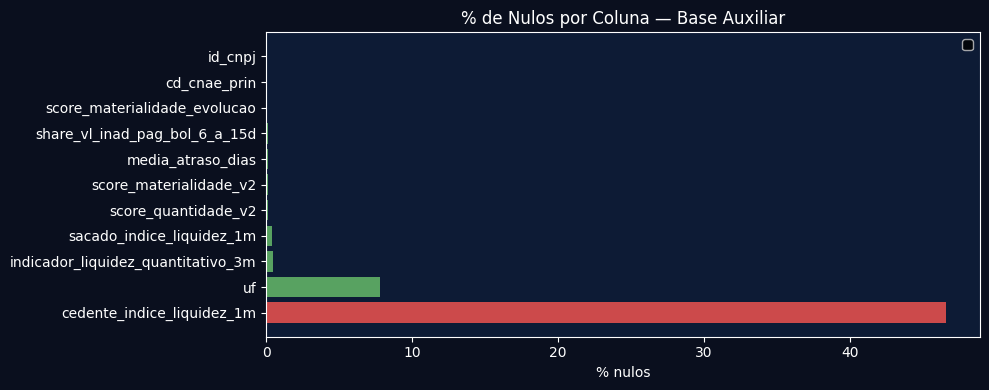

cedente_indice_liquidez_1m: ~47% nulos — mantida com imputacao por mediana (fit no treino)


In [145]:
nulos = df_aux.isnull().mean().sort_values(ascending=False) * 100
fig, ax = plt.subplots(figsize=(10, 4), facecolor='#0a0f1e')
colors = [C['risco'] if v > 30 else C['warn'] if v > 10 else C['ok'] for v in nulos.values]
ax.barh(nulos.index, nulos.values, color=colors, alpha=0.85)
ax.set_title('% de Nulos por Coluna — Base Auxiliar', color='white')
ax.set_xlabel('% nulos'); ax.set_facecolor(C['bg'])
ax.legend(); plt.tight_layout(); plt.show()

print('cedente_indice_liquidez_1m: ~47% nulos — mantida com imputacao por mediana (fit no treino)')

## 5. Feature Engineering — Agregação por Beneficiário

In [ ]:
def build_features(df_boletos, df_aux):
    """
    Agrega boletos por beneficiario e faz join com a base auxiliar.
    Recebe df_boletos ja filtrado (treino ou validacao).
    Os targets pd_30/60/90 sao a proporcao continua de boletos em atraso [0,1].
    """
    df = df_boletos.copy()
    df['pct_baixa_vs_nominal'] = (df['vlr_baixa'] / df['vlr_nominal']).clip(0, 1)

    agg = df.groupby(['id_beneficiario']).agg(
        total_boletos        = ('id_boleto',             'count'),
        vlr_total            = ('vlr_nominal',           'sum'),
        vlr_medio            = ('vlr_nominal',           'mean'),
        vlr_std              = ('vlr_nominal',           'std'),
        pct_atraso_geral     = ('em_atraso',             'mean'),
        pd_30                = ('atraso_30',             'mean'),  # target continuo [0,1]
        pd_60                = ('atraso_60',             'mean'),  # target continuo [0,1]
        pd_90                = ('atraso_90',             'mean'),  # target continuo [0,1]
        dpd_medio            = ('dpd', lambda x: x[x < 999].mean() if (x < 999).any() else 0),
        dpd_max              = ('dpd', lambda x: x[x < 999].max()  if (x < 999).any() else 0),
        n_pagadores_unicos   = ('id_pagador',            'nunique'),
        meses_ativo          = ('mes_emissao',           'nunique'),
        n_especies           = ('tipo_especie',          'nunique'),
        pct_baixa_vs_nominal = ('pct_baixa_vs_nominal',  lambda x: x.fillna(0).mean()),
    ).reset_index()

    agg['atraso_cronico'] = (agg['dpd_medio'] > 30).astype(int)

    conc = df.groupby(['id_beneficiario', 'id_pagador'])['vlr_nominal'].sum().reset_index()
    conc_top = (
        conc.sort_values('vlr_nominal', ascending=False)
            .groupby('id_beneficiario').first().reset_index()
            .rename(columns={'vlr_nominal': 'vlr_top_pagador'})
    )
    total_vlr = df.groupby('id_beneficiario')['vlr_nominal'].sum().reset_index()
    conc_top  = conc_top.merge(total_vlr, on='id_beneficiario')
    conc_top['concentracao_top1'] = conc_top['vlr_top_pagador'] / conc_top['vlr_nominal']
    agg = agg.merge(conc_top[['id_beneficiario', 'concentracao_top1']], on='id_beneficiario', how='left')

    ultimo = df.groupby('id_beneficiario')['dt_emissao'].max().reset_index()
    ultimo['dias_desde_ultimo'] = (df['dt_emissao'].max() - ultimo['dt_emissao']).dt.days
    agg = agg.merge(ultimo[['id_beneficiario', 'dias_desde_ultimo']], on='id_beneficiario', how='left')

    # Join auxiliar
    aux_cols = [
        'id_cnpj', 'cd_cnae_prin', 'uf',
        'sacado_indice_liquidez_1m',
        'cedente_indice_liquidez_1m',
        'score_materialidade_evolucao',
        'media_atraso_dias',
        'indicador_liquidez_quantitativo_3m',
        'share_vl_inad_pag_bol_6_a_15d',
        'score_quantidade',
        'score_materialidade',
    ]
    aux = df_aux[aux_cols].copy()
    aux['uf_cod']   = aux['uf'].astype('category').cat.codes
    aux['cnae_cod'] = aux['cd_cnae_prin'].astype('category').cat.codes
    aux = aux.drop(columns=['uf', 'cd_cnae_prin'])

    resultado = agg.merge(aux, left_on='id_beneficiario', right_on='id_cnpj', how='left')
    return resultado.drop(columns=['id_cnpj'], errors='ignore')


def obter_foto_cliente(df_bol_full, df_aux_full, data_corte):

    df_hist = df_bol_full[df_bol_full['dt_emissao'] < data_corte].copy()
    X = build_features(df_hist, df_aux_full)
    X = X.rename(columns={'pd_30': 'pd_30_hist', 'pd_60': 'pd_60_hist', 'pd_90': 'pd_90_hist'})
    return X

#iremos avaliar a performance do modelo em treinamento com dados < mar/2024
X_train_final = obter_foto_cliente(df_bol_train, df_aux, '2024-03-01')
y_train_final = df_bol[df_bol['dt_emissao'].dt.to_period('M') == '2024-03'].groupby('id_beneficiario').agg(
    pd_30 = ('atraso_30', 'mean'),
    pd_60 = ('atraso_60', 'mean'),
    pd_90 = ('atraso_90', 'mean')
).reset_index()

Boletos com pagamento parcial (<99% nominal): 0.3%


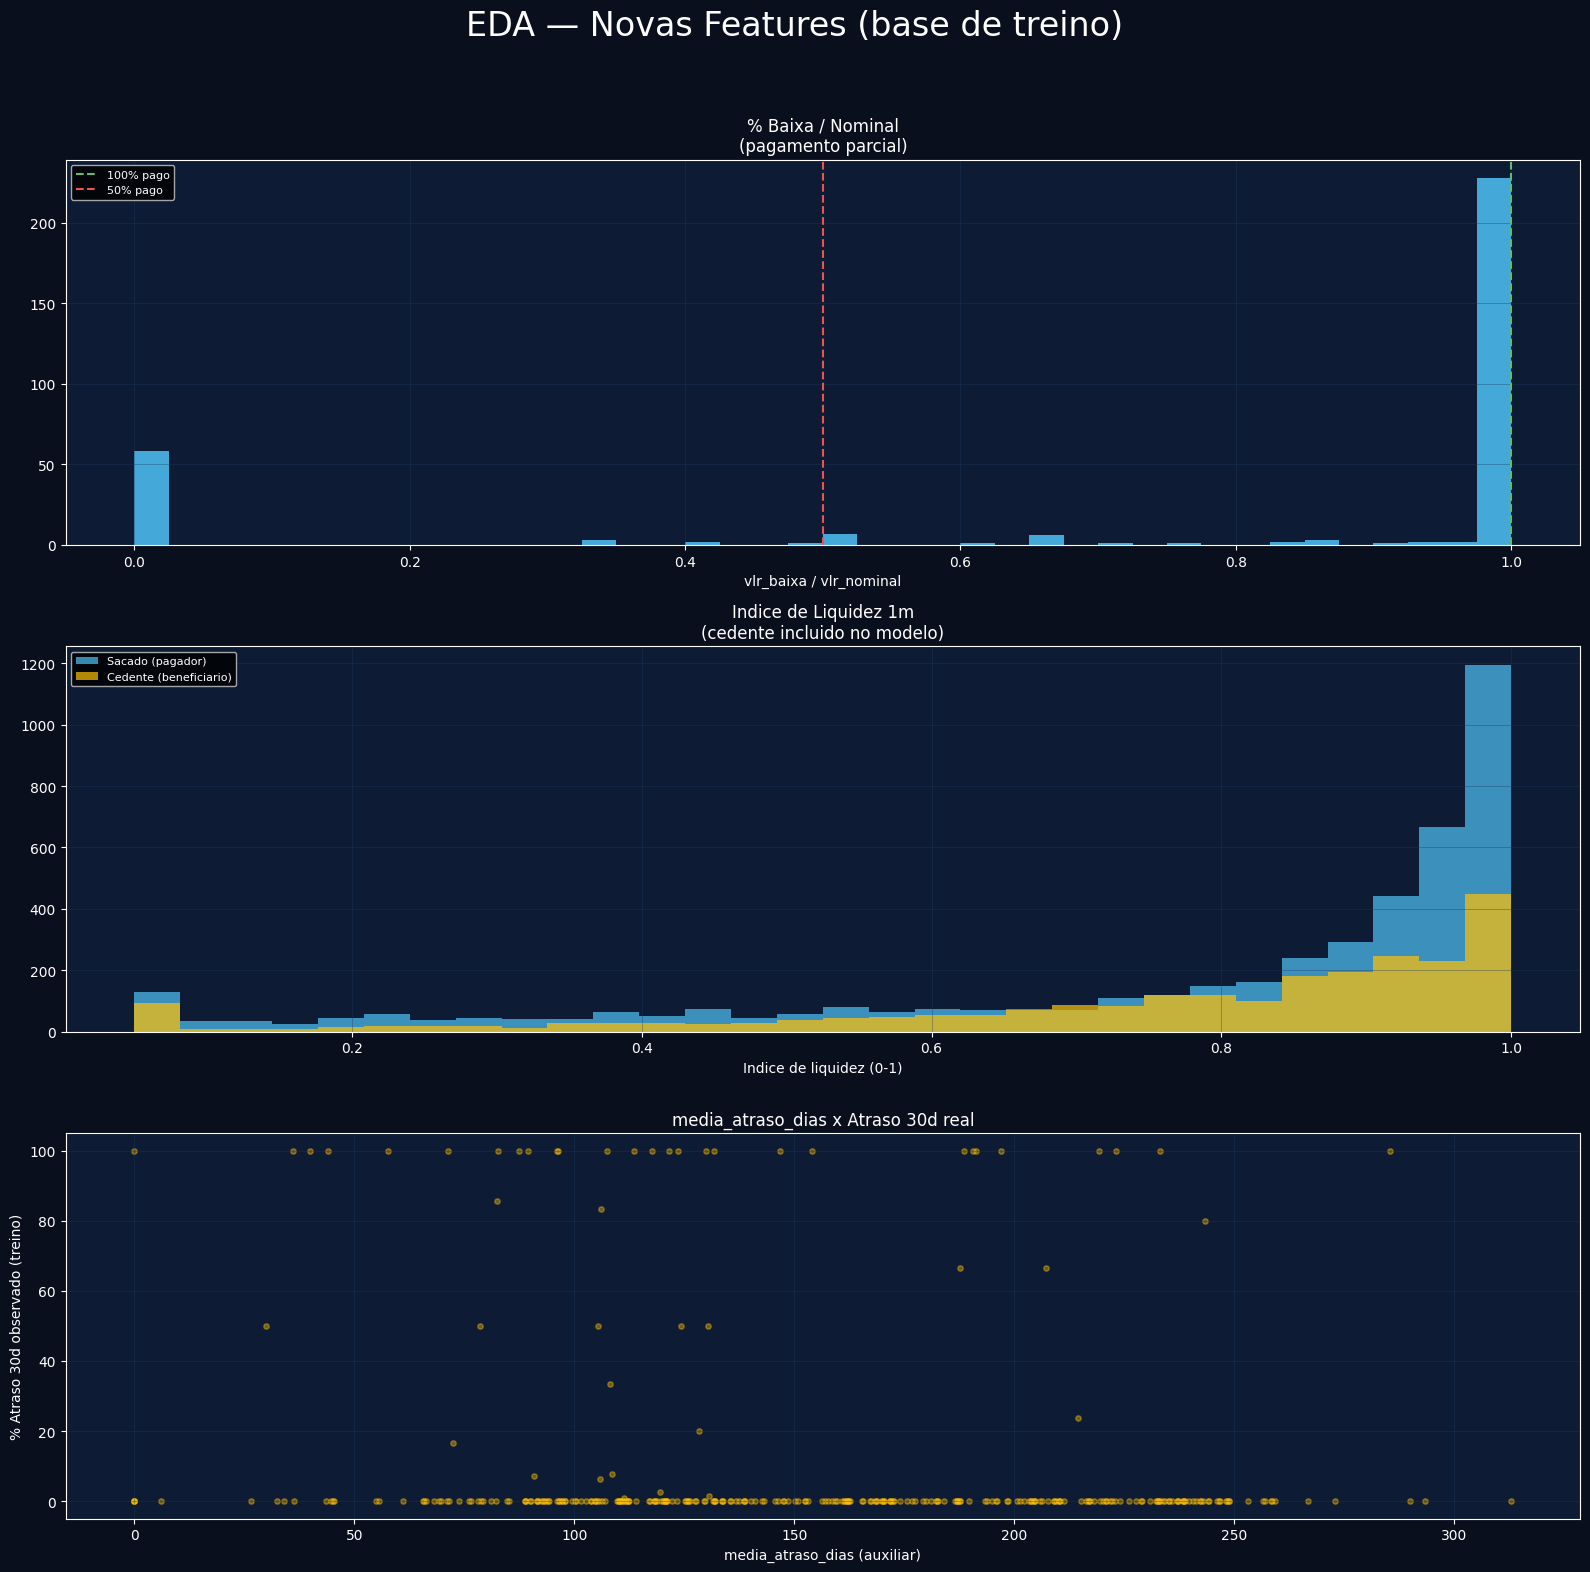

In [182]:
fig, axes = plt.subplots(nrows= 3, ncols=1, figsize=(16, 16), facecolor='#0a0f1e')
fig.suptitle('EDA — Novas Features (base de treino)\n\n', color='white', fontsize=24)

# Plot 1: pct_baixa_vs_nominal
pct_bx = X_train_final['pct_baixa_vs_nominal'].dropna()
axes[0].hist(pct_bx, bins=40, color=C['neutro'], alpha=0.85)
axes[0].axvline(1.0, color=C['ok'],    linestyle='--', label='100% pago')
axes[0].axvline(0.5, color=C['risco'], linestyle='--', label='50% pago')
axes[0].set_title('% Baixa / Nominal\n(pagamento parcial)', color='white')
axes[0].set_xlabel('vlr_baixa / vlr_nominal'); axes[0].legend(fontsize=8)
print(f'Boletos com pagamento parcial (<99% nominal): {(df_bol_train["pct_baixa_vs_nominal"] < 0.99).mean()*100:.1f}%')

# Plot 2: cedente vs sacado liquidez
liq_ced = df_aux['cedente_indice_liquidez_1m'].dropna()
liq_sac = df_aux['sacado_indice_liquidez_1m'].dropna()
axes[1].hist(liq_sac, bins=30, color=C['neutro'], alpha=0.7, label='Sacado (pagador)')
axes[1].hist(liq_ced, bins=30, color=C['warn'],   alpha=0.7, label='Cedente (beneficiario)')
axes[1].set_title('Indice de Liquidez 1m\n(cedente incluido no modelo)', color='white')
axes[1].set_xlabel('Indice de liquidez (0-1)'); axes[1].legend(fontsize=8)

# Plot 3: media_atraso_dias x taxa real de atraso 30d
axes[2].scatter(
    X_train_final['media_atraso_dias'],
    X_train_final['pd_30_hist'] * 100,
    color=C['warn'], alpha=0.4, s=15
)
axes[2].set_title('media_atraso_dias x Atraso 30d real', color='white')
axes[2].set_xlabel('media_atraso_dias (auxiliar)')
axes[2].set_ylabel('% Atraso 30d observado (treino)')

for ax in axes:
    ax.set_facecolor(C['bg'])
    ax.grid(color=C['grid'], linewidth=0.5, alpha=0.5)

plt.tight_layout(); plt.show()


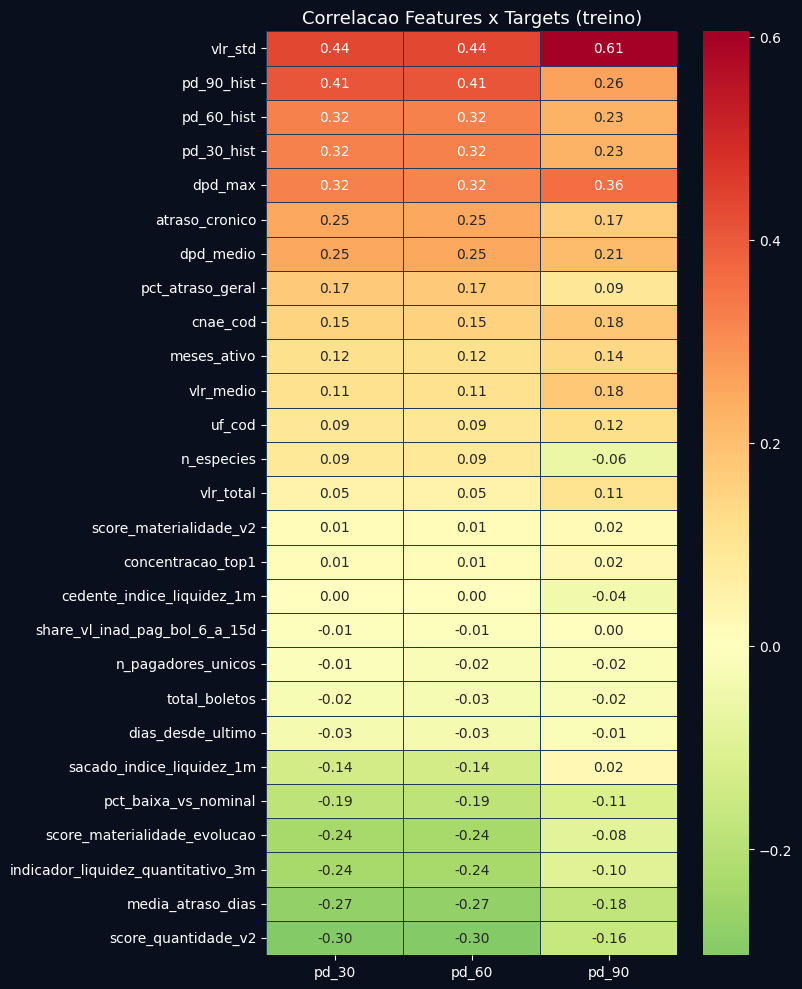

In [ ]:
FEATURE_COLS = [
    'total_boletos', 'vlr_total', 'vlr_medio', 'vlr_std',
    'pct_atraso_geral', 'dpd_medio', 'dpd_max',
    'n_pagadores_unicos', 'meses_ativo', 'n_especies',
    'concentracao_top1', 'dias_desde_ultimo',
    'pct_baixa_vs_nominal', 'atraso_cronico',
    'sacado_indice_liquidez_1m', 'cedente_indice_liquidez_1m',
    'score_materialidade_evolucao', 'media_atraso_dias',
    'indicador_liquidez_quantitativo_3m', 'share_vl_inad_pag_bol_6_a_15d',
    'score_quantidade', 'score_materialidade',
    'uf_cod', 'cnae_cod', 'pd_30_hist', 'pd_60_hist', 'pd_90_hist'
]

df_analise = X_train_final.merge(y_train_final, on='id_beneficiario').drop(columns='id_beneficiario')

# 2. Ver quais features mais correlacionam com o atraso de Março
corr_matrix = df_analise[FEATURE_COLS + TARGETS].corr()
corr_filtered = corr_matrix.loc[FEATURE_COLS, TARGETS]
corr_filtered = corr_filtered.sort_values(by='pd_30', ascending=False)

fig, ax = plt.subplots(figsize=(8, 10), facecolor='#0a0f1e')
sns.heatmap(corr_filtered, annot=True, fmt='.2f', cmap='RdYlGn_r',
            center=0, ax=ax, linewidths=0.5, linecolor='#1e3a5f')
ax.set_title('Correlacao Features x Targets (treino)', color='white', fontsize=13)
ax.set_facecolor(C['bg'])
plt.tight_layout(); plt.show()

## 6. Preparação de X e y

#### Mudar só para a coluna especifica com o % de nulos alto!

In [184]:
X_train_para_imputer = X_train_final[FEATURE_COLS]

imputer = SimpleImputer(strategy='median')
X_train_imp = imputer.fit_transform(X_train_para_imputer)

joblib.dump(imputer, MODEL_DIR / 'imputer.pkl')

['models\\imputer.pkl']

## 7. Avaliação dos modelos no conjunto de treino

### 7a. Baseline — Ridge Regression

In [185]:
TARGETS_MODELO = ['pd_30', 'pd_60', 'pd_90']
resultados_baseline = {}

for target in TARGETS_MODELO:
    df_treino_alinhado = pd.DataFrame(X_train_imp, columns=FEATURE_COLS)
    df_treino_alinhado['id_beneficiario'] = X_train_final['id_beneficiario'].values
    
    df_final_ciclo = df_treino_alinhado.merge(y_train_final[['id_beneficiario', target]], on='id_beneficiario')
    
    X_input = df_final_ciclo[FEATURE_COLS]
    y_true  = df_final_ciclo[target]
    
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('ridge',  Ridge(alpha=1.0)),
    ])
    
    pipe.fit(X_input, y_true)
    y_pred = pipe.predict(X_input).clip(0, 1)

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    rho  = stats.spearmanr(y_true, y_pred).correlation

    resultados_baseline[target] = {
        'rmse': rmse, 
        'mae': mae, 
        'r2': r2, 
        'rho': rho, 
        'model': pipe
    }
    
    print(f'[Baseline Treino] {target.upper()} -> RMSE: {rmse:.4f} | MAE: {mae:.4f} | R2: {r2:.4f} | Spearman: {rho:.4f}')

[Baseline Treino] PD_30 -> RMSE: 0.0960 | MAE: 0.0516 | R2: 0.5812 | Spearman: 0.3173
[Baseline Treino] PD_60 -> RMSE: 0.0960 | MAE: 0.0515 | R2: 0.5816 | Spearman: 0.3165
[Baseline Treino] PD_90 -> RMSE: 0.0652 | MAE: 0.0290 | R2: 0.6243 | Spearman: 0.1595


### 7b. XGBoost

In [186]:
TARGETS_MODELO = ['pd_30', 'pd_60', 'pd_90']
resultados_xgboost = {}

for target in TARGETS_MODELO:
    df_treino_alinhado = pd.DataFrame(X_train_imp, columns=FEATURE_COLS)
    df_treino_alinhado['id_beneficiario'] = X_train_final['id_beneficiario'].values
    
    df_final_ciclo = df_treino_alinhado.merge(y_train_final[['id_beneficiario', target]], on='id_beneficiario')
    
    X_input = df_final_ciclo[FEATURE_COLS]
    y_true  = df_final_ciclo[target]
    
    model_xgb = XGBRegressor(
        n_estimators=500,
        learning_rate=0.01,
        max_depth=2,          
        min_child_weight=10,   
        reg_lambda=20,         
        subsample=0.6,         
        colsample_bytree=0.6,  
        random_state=42,
        n_jobs=-1
    )
    
    model_xgb.fit(X_input, y_true)
    
    y_pred_train = model_xgb.predict(X_input).clip(0, 1)
    rho_train = stats.spearmanr(y_true, y_pred_train).correlation
    
    resultados_xgboost[target] = {'model': model_xgb}


    rmse = np.sqrt(mean_squared_error(y_true, y_pred_train))
    mae  = mean_absolute_error(y_true, y_pred_train)
    r2   = r2_score(y_true, y_pred_train)
    rho  = stats.spearmanr(y_true, y_pred_train).correlation

    resultados_xgboost[target] = {
        'rmse': rmse, 
        'mae': mae, 
        'r2': r2, 
        'rho': rho, 
        'model': model_xgb
    }
    
    print(f'[XGBoost Treino] {target.upper()} -> RMSE: {rmse:.4f} | MAE: {mae:.4f} | R2: {r2:.4f} | Spearman: {rho:.4f}')

[XGBoost Treino] PD_30 -> RMSE: 0.1171 | MAE: 0.0488 | R2: 0.3769 | Spearman: 0.3821
[XGBoost Treino] PD_60 -> RMSE: 0.1171 | MAE: 0.0488 | R2: 0.3774 | Spearman: 0.3769
[XGBoost Treino] PD_90 -> RMSE: 0.0951 | MAE: 0.0235 | R2: 0.1998 | Spearman: 0.3018


## 8. Avaliação dos modelos no conjunto de validação

### 8a. Baseline — Ridge Regression

In [187]:
X_valid = obter_foto_cliente(df_bol_train, df_aux, '2024-04-01')
y_valid = df_bol_valid[df_bol_valid['dt_emissao'].dt.to_period('M') >= '2024-04'].groupby('id_beneficiario').agg(
    pd_30 = ('atraso_30', 'mean'),
    pd_60 = ('atraso_60', 'mean'),
    pd_90 = ('atraso_90', 'mean')
).reset_index()

X_valid_para_imputer = X_valid[FEATURE_COLS]
X_valid_imp = imputer.transform(X_valid_para_imputer)

resultados_validacao_ridge = {}

for target in TARGETS_MODELO:
    df_valid_alinhado = pd.DataFrame(X_valid_imp, columns=FEATURE_COLS)
    df_valid_alinhado['id_beneficiario'] = X_valid['id_beneficiario'].values
    
    df_final_valid = df_valid_alinhado.merge(y_valid[['id_beneficiario', target]], on='id_beneficiario')
    
    X_val_input = df_final_valid[FEATURE_COLS]
    y_val_true  = df_final_valid[target]
    
    modelo_treinado_ridge = resultados_baseline[target]['model']
    y_val_pred = modelo_treinado_ridge.predict(X_val_input).clip(0, 1)

    rmse_v = np.sqrt(mean_squared_error(y_val_true, y_val_pred))
    mae_v  = mean_absolute_error(y_val_true, y_val_pred)
    r2_v   = r2_score(y_val_true, y_val_pred)
    rho_v  = stats.spearmanr(y_val_true, y_val_pred).correlation

    resultados_validacao_ridge[target] = {'rmse': rmse_v, 'mae': mae_v, 'r2': r2_v, 'rho': rho_v}
    
    print(f'[Ridge Validação] {target.upper()} -> RMSE: {rmse_v:.4f} | MAE: {mae_v:.4f} | R2: {r2_v:.4f} | Spearman: {rho_v:.4f}')

[Ridge Validação] PD_30 -> RMSE: 0.1732 | MAE: 0.0669 | R2: -0.3769 | Spearman: 0.1508
[Ridge Validação] PD_60 -> RMSE: 0.1621 | MAE: 0.0629 | R2: -0.4808 | Spearman: 0.1558
[Ridge Validação] PD_90 -> RMSE: 0.1243 | MAE: 0.0443 | R2: -0.5328 | Spearman: 0.0592


### 8b. XGBoost

In [189]:
# Loop de Validação
for target in TARGETS_MODELO:
    df_valid_alinhado = pd.DataFrame(X_valid_imp, columns=FEATURE_COLS)
    df_valid_alinhado['id_beneficiario'] = X_valid['id_beneficiario'].values
    
    df_final_valid = df_valid_alinhado.merge(y_valid[['id_beneficiario', target]], on='id_beneficiario')
    
    X_val_input = df_final_valid[FEATURE_COLS]
    y_val_true  = df_final_valid[target]
    
    modelo_treinado = resultados_xgboost[target]['model']
    y_val_pred = modelo_treinado.predict(X_val_input).clip(0, 1)

    rmse_v = np.sqrt(mean_squared_error(y_val_true, y_val_pred))
    mae_v  = mean_absolute_error(y_val_true, y_val_pred)
    r2_v   = r2_score(y_val_true, y_val_pred)
    rho_v = stats.spearmanr(y_val_true, y_val_pred).correlation
    print(f'[XGBoost Validação] {target.upper()} -> RMSE: {rmse_v:.4f} | MAE: {mae_v:.4f} | R2: {r2_v:.4f} | Spearman: {rho_v:.4f}')

[XGBoost Validação] PD_30 -> RMSE: 0.1449 | MAE: 0.0553 | R2: 0.0365 | Spearman: 0.1812
[XGBoost Validação] PD_60 -> RMSE: 0.1291 | MAE: 0.0501 | R2: 0.0604 | Spearman: 0.2187
[XGBoost Validação] PD_90 -> RMSE: 0.1014 | MAE: 0.0284 | R2: -0.0191 | Spearman: 0.0533


O modelo que melhor performou nos dados de validação e treinamento foi o XGBoost, portanto, ele será o modelo escolhido. No entanto, apenas os PD_30 e PD_60 obtiveram resultados satisfatórios, então seguiremos com a ideia de predizer somente eles, e não mais o PD_90.

## 10. Feature Importance

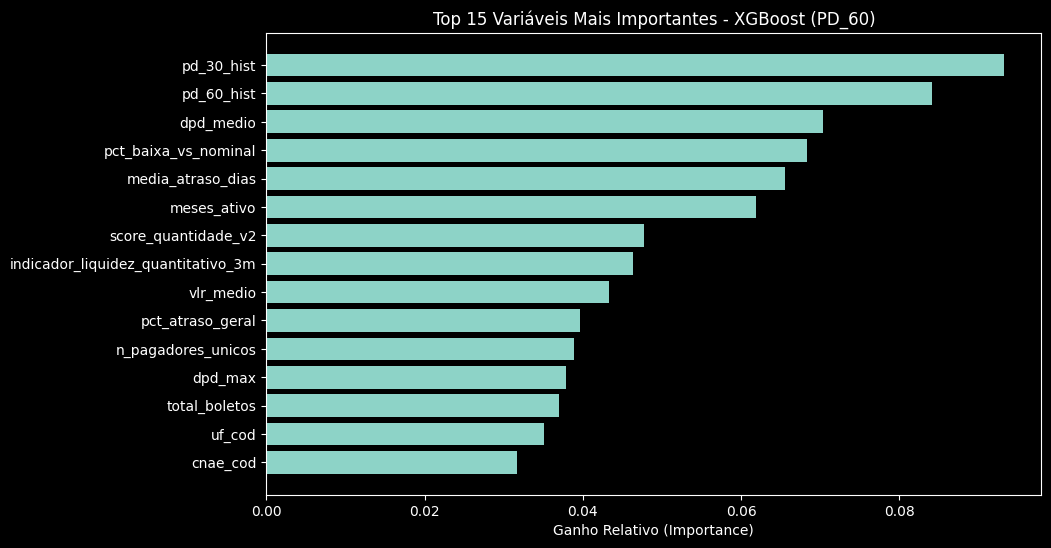

                               feature  importancia
24                          pd_30_hist       0.0933
25                          pd_60_hist       0.0841
5                            dpd_medio       0.0703
12                pct_baixa_vs_nominal       0.0683
17                   media_atraso_dias       0.0655
8                          meses_ativo       0.0618
20                 score_quantidade_v2       0.0477
18  indicador_liquidez_quantitativo_3m       0.0463
2                            vlr_medio       0.0433
4                     pct_atraso_geral       0.0397


In [ ]:
import matplotlib.pyplot as plt

# Extrair as importâncias do modelo PD_60 
modelo_vencedor = resultados_xgboost['pd_60']['model']
importancias = modelo_vencedor.feature_importances_

# Criar DataFrame para facilitar a visualização
df_importancia = pd.DataFrame({
    'feature': FEATURE_COLS,
    'importancia': importancias
}).sort_values(ascending=False, by='importancia')

# Plotar os 15 primeiros
plt.figure(figsize=(10, 6))
plt.barh(df_importancia['feature'].head(15)[::-1], df_importancia['importancia'].head(15)[::-1])
plt.title('Top 15 Variáveis Mais Importantes - XGBoost (PD_60)')
plt.xlabel('Ganho Relativo (Importance)')
plt.show()

print(df_importancia.head(10))

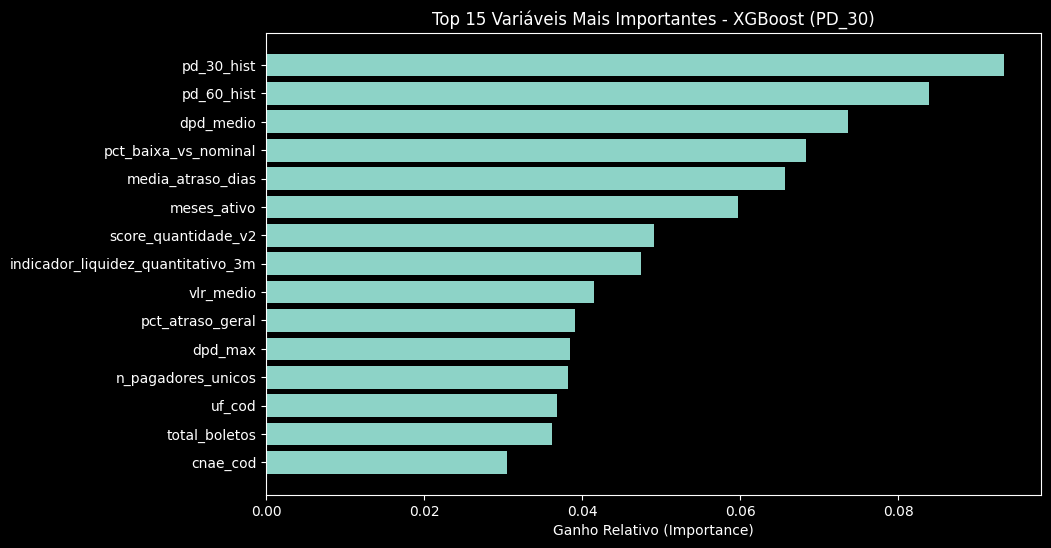

                               feature  importancia
24                          pd_30_hist       0.0935
25                          pd_60_hist       0.0839
5                            dpd_medio       0.0736
12                pct_baixa_vs_nominal       0.0683
17                   media_atraso_dias       0.0657
8                          meses_ativo       0.0597
20                 score_quantidade_v2       0.0491
18  indicador_liquidez_quantitativo_3m       0.0474
2                            vlr_medio       0.0415
4                     pct_atraso_geral       0.0391


In [ ]:
import matplotlib.pyplot as plt

# Extrair as importâncias do modelo PD_30
modelo_vencedor = resultados_xgboost['pd_30']['model']
importancias = modelo_vencedor.feature_importances_

df_importancia = pd.DataFrame({
    'feature': FEATURE_COLS,
    'importancia': importancias
}).sort_values(ascending=False, by='importancia')

plt.figure(figsize=(10, 6))
plt.barh(df_importancia['feature'].head(15)[::-1], df_importancia['importancia'].head(15)[::-1])
plt.title('Top 15 Variáveis Mais Importantes - XGBoost (PD_30)')
plt.xlabel('Ganho Relativo (Importance)')
plt.show()

print(df_importancia.head(10))

## 11. SHAP Values — Explicabilidade


=== SHAP Beeswarm — PD_30 ===


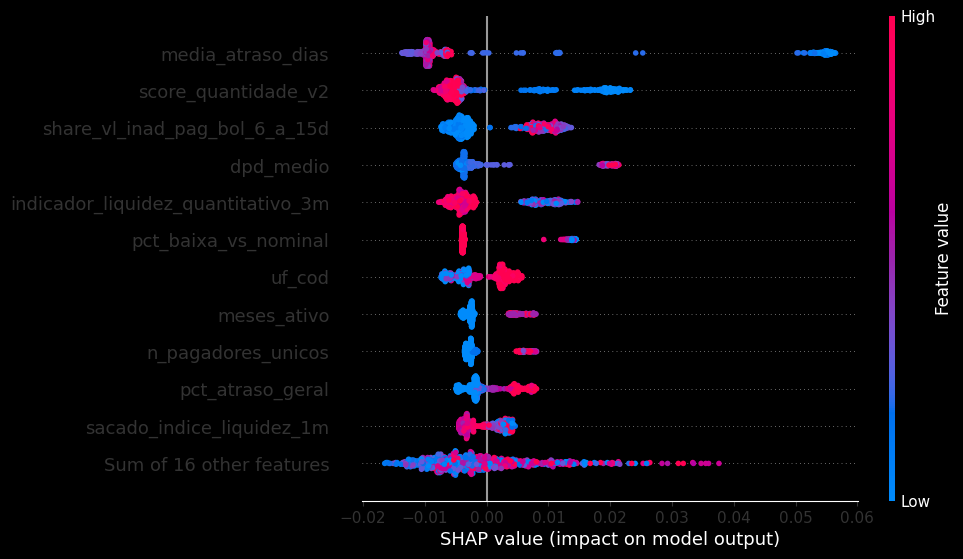


=== SHAP Beeswarm — PD_60 ===


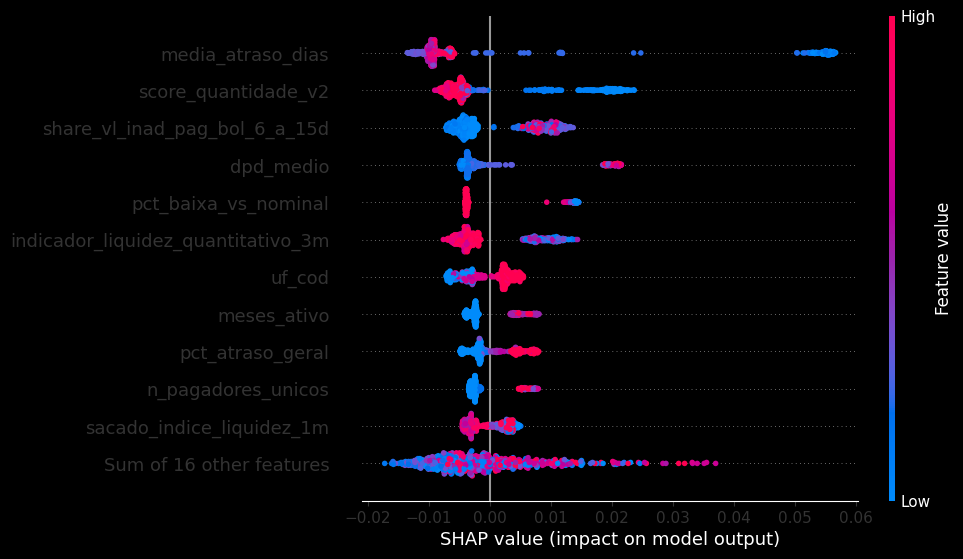

In [ ]:
TARGETS.remove('pd_90')
shap_explicadores = {}
shap_valores      = {}

for target in TARGETS:
    explainer = shap.TreeExplainer(resultados_xgboost[target]['model'])
    sv = explainer(X_valid_imp)
    sv.feature_names = FEATURE_COLS
    shap_explicadores[target] = explainer
    shap_valores[target]      = sv

for target in TARGETS:
    print(f'\n=== SHAP Beeswarm — {target.upper()} ===')
    shap.plots.beeswarm(shap_valores[target], max_display=12, show=True)

## Modelo Clientes Novos

O modelo de Clientes Novos será usado para aqueles clientes que só possuem até 2 meses de histórico na nossa base - ou seja, que tem pouco ou nenhum histórico de comportamento na base de boletos, e portanto só usarão as informações da base auxiliar. No entanto, como muitas dessas variáveis ainda tem a ver com o comportamento do cliente nos últimos meses, só iremos treinar e validar o modelo nos clientes novos na referência de abril/2024.

In [198]:
# 1. Achar a data do primeiro boleto de cada beneficiário na história toda
df_nascimento = df_bol.groupby('id_beneficiario')['dt_emissao'].min().reset_index()
df_nascimento.columns = ['id_beneficiario', 'data_primeiro_boleto']

# 2. Definir a data da sua foto de validação
data_ref_valid = pd.to_datetime('2024-04-01')

# 3. Calcular a diferença em meses
df_nascimento['meses_de_casa'] = (
    (data_ref_valid.year - df_nascimento['data_primeiro_boleto'].dt.year) * 12 +
    (data_ref_valid.month - df_nascimento['data_primeiro_boleto'].dt.month)
)

# 4. Filtrar quem tem entre 0 e 2 meses de histórico em 01/04/2024
ids_novos = df_nascimento[
    (df_nascimento['meses_de_casa'] >= 0) & 
    (df_nascimento['meses_de_casa'] <= 2)
]['id_beneficiario'].unique()

print(f"Total de clientes novos (0-2 meses) para validação: {len(ids_novos)}")

Total de clientes novos (0-2 meses) para validação: 960


In [220]:
df_novos = df_bol[df_bol['id_beneficiario'].isin(ids_novos)]


df_target_mensal = df_bol[df_bol['id_beneficiario'].isin(ids_novos)].groupby(['id_beneficiario']).agg(
    pd_30 = ('atraso_30', 'mean'),
    pd_60 = ('atraso_60', 'mean')
).reset_index()

df_modelagem_novos = df_target_mensal.merge(
    df_aux, 
    left_on='id_beneficiario', 
    right_on= 'id_cnpj',
    how='inner'
)
mapa_regioes = {
    'AC': 'Norte', 'AM': 'Norte', 'AP': 'Norte', 'PA': 'Norte', 'RO': 'Norte', 'RR': 'Norte', 'TO': 'Norte',
    'AL': 'Nordeste', 'BA': 'Nordeste', 'CE': 'Nordeste', 'MA': 'Nordeste', 'PB': 'Nordeste', 
    'PE': 'Nordeste', 'PI': 'Nordeste', 'RN': 'Nordeste', 'SE': 'Nordeste',
    'DF': 'Centro-Oeste', 'GO': 'Centro-Oeste', 'MT': 'Centro-Oeste', 'MS': 'Centro-Oeste',
    'ES': 'Sudeste', 'MG': 'Sudeste', 'RJ': 'Sudeste', 'SP': 'Sudeste',
    'PR': 'Sul', 'RS': 'Sul', 'SC': 'Sul'
}
df_modelagem_novos['regiao'] = df_modelagem_novos['uf'].map(mapa_regioes)
df_modelagem_novos = pd.get_dummies(df_modelagem_novos, columns=['regiao'], prefix='reg', prefix_sep='_')
df_modelagem_novos = df_modelagem_novos.drop(columns=['uf'])


In [221]:
targets = ['pd_30', 'pd_60']
controles = ['id_beneficiario', 'id_cnpj']

feature_cols_novos = [c for c in df_modelagem_novos.columns if c not in targets + controles]

X = df_modelagem_novos[feature_cols_novos]
y = df_modelagem_novos[targets]

# Split por ID (para não ter o mesmo cliente no treino e teste em meses diferentes)
from sklearn.model_selection import train_test_split

ids_unicos = df_modelagem_novos['id_beneficiario'].unique().tolist()

ids_train, ids_test = train_test_split(
    ids_unicos, 
    test_size=0.3, 
    random_state=42
)

feature_cols_novos = [c for c in df_modelagem_novos.columns if c not in targets + controles]

# Filtragem usando .loc para maior segurança
X_train_n = df_modelagem_novos.loc[df_modelagem_novos['id_beneficiario'].isin(ids_train), feature_cols_novos].copy()
y_train_n = df_modelagem_novos.loc[df_modelagem_novos['id_beneficiario'].isin(ids_train), targets].copy()

X_test_n = df_modelagem_novos.loc[df_modelagem_novos['id_beneficiario'].isin(ids_test), feature_cols_novos].copy()
y_test_n = df_modelagem_novos.loc[df_modelagem_novos['id_beneficiario'].isin(ids_test), targets].copy()

print(f"Treino: {X_train_n.shape[0]} linhas | Teste: {X_test_n.shape[0]} linhas\n")

Treino: 672 linhas | Teste: 288 linhas



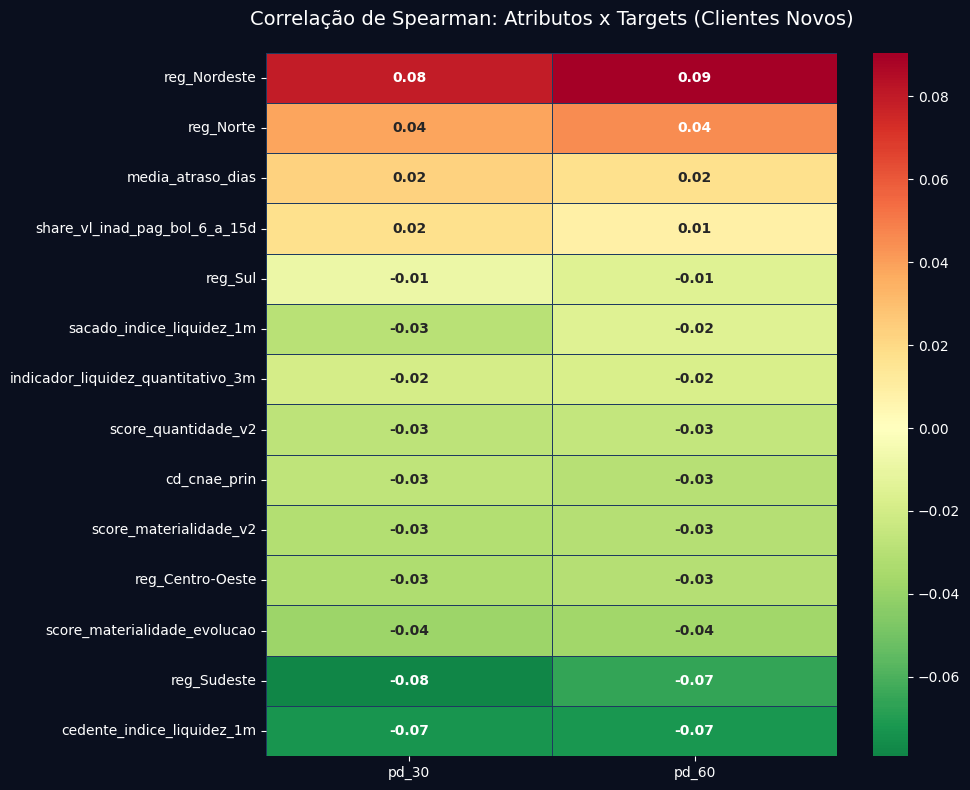

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns # Certifique-se de que o seaborn está como sns
import pandas as pd
import numpy as np

# 1. Criar o df para análise a partir do treino
df_analise_novos = X_train_n.copy()
df_analise_novos['pd_30'] = y_train_n['pd_30'].values
df_analise_novos['pd_60'] = y_train_n['pd_60'].values


# 3. Calcular a matriz de correlação de Spearman
corr_matrix = df_analise_novos.corr(method='spearman')

# 4. Isolar Features vs Targets
targets_cols = ['pd_30', 'pd_60']
feature_cols = [c for c in df_analise_novos.columns if c not in targets_cols]

corr_filtered = corr_matrix.loc[feature_cols, targets_cols]
corr_filtered = corr_filtered.sort_values(by='pd_60', ascending=False)

plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(10, 8), facecolor='#0a0f1e')

sns.heatmap(
    corr_filtered, 
    annot=True, 
    fmt='.2f', 
    cmap='RdYlGn_r', 
    center=0, 
    ax=ax, 
    linewidths=0.5, 
    linecolor='#1e3a5f',
    annot_kws={"size": 10, "weight": "bold"}
)

ax.set_title('Correlação de Spearman: Atributos x Targets (Clientes Novos)', 
             color='white', fontsize=14, pad=20)

plt.tight_layout()
plt.show()

In [224]:
colunas_para_remover = ['id_cnpj']
feature_cols_limpas = [c for c in feature_cols_novos if c not in colunas_para_remover]

# 2. Converter colunas de texto restantes (como UF e CNAE) para 'category'
X_train_n = X_train_n[feature_cols_limpas].copy()
X_test_n = X_test_n[feature_cols_limpas].copy()


resultados_novos = {}

for target in targets:
    # Configuração conservadora para baixo volume de dados
    model = XGBRegressor(
        n_estimators=50,          # Reduzimos de 150 para 50
        learning_rate=0.02,       # Passos menores
        max_depth=2,              # Árvores minúsculas (apenas 2 níveis)
        min_child_weight=10,      # Exige ainda mais clientes por folha
        reg_lambda=50,            # Penalidade L2 altíssima para evitar pesos grandes
        enable_categorical=True,
        tree_method="hist",
        random_state=42
    )
    
    # Treino
    model.fit(X_train_n, y_train_n[target])
    
    # Predição (Limitando entre 0 e 1)
    y_pred_train = model.predict(X_train_n).clip(0, 1)
    y_pred_test = model.predict(X_test_n).clip(0, 1)
    
    # Cálculo do Spearman
    rho_train = stats.spearmanr(y_train_n[target], y_pred_train).correlation
    rho_test = stats.spearmanr(y_test_n[target], y_pred_test).correlation
    
    resultados_novos[target] = {
        'model': model,
        'spearman_train': rho_train,
        'spearman_test': rho_test,
        'predictions': y_pred_test
    }
    
    print(f"=== Resultados para {target.upper()} ===")
    print(f"Spearman (Treino): {rho_train:.4f}")
    print(f"Spearman (Teste):  {rho_test:.4f}")
    print("-" * 30)

=== Resultados para PD_30 ===
Spearman (Treino): 0.1715
Spearman (Teste):  -0.0136
------------------------------
=== Resultados para PD_60 ===
Spearman (Treino): 0.1780
Spearman (Teste):  -0.0182
------------------------------


Os resultados do modelo de Clientes Novos não foram satisfatórios, então vamos seguir somente com o modelo de Recorrentes.

## 12. Exportação do Modelo

In [225]:
import joblib
import json
from pathlib import Path

# 1. Definir e criar o diretório de exportação
MODEL_DIR = Path('modelos_exportados')
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# 2. Exportar o Imputer (Fundamental para novos dados!)
# Assumindo que seu objeto se chama 'imputer' (o que você usou no fit_transform)
if 'imputer' in locals():
    joblib.dump(imputer, MODEL_DIR / 'imputer_recorrentes.pkl')
    print(f'✅ Imputer salvo: imputer_recorrentes.pkl')
else:
    print('⚠️ Aviso: Objeto "imputer" não encontrado na memória.')

# 3. Exportar os modelos do dicionário resultados_xgboost
for target in TARGETS_MODELO:
    if target in resultados_xgboost:
        model_path = MODEL_DIR / f'xgb_{target}.pkl'
        # Acessa o modelo conforme a estrutura que você criou: ['model']
        joblib.dump(resultados_xgboost[target]['model'], model_path)
        print(f'✅ Modelo salvo: {model_path.name}')

# 4. Exportar a lista de features (FEATURE_COLS)
# Isso garante que você saiba a ordem exata das colunas na produção
with open(MODEL_DIR / 'feature_cols.json', 'w') as f:
    json.dump(FEATURE_COLS, f, indent=2)
print('✅ feature_cols.json salvo')

# 5. Listar arquivos exportados e tamanhos
print('\nConteúdo da pasta de exportação:')
for p in sorted(MODEL_DIR.iterdir()):
    print(f'  {p.name} ({p.stat().st_size/1024:.1f} KB)')

✅ Imputer salvo: imputer_recorrentes.pkl
✅ Modelo salvo: xgb_pd_30.pkl
✅ Modelo salvo: xgb_pd_60.pkl
✅ Modelo salvo: xgb_pd_90.pkl
✅ feature_cols.json salvo

Conteúdo da pasta de exportação:
  feature_cols.json (0.6 KB)
  imputer_recorrentes.pkl (1.4 KB)
  xgb_pd_30.pkl (415.3 KB)
  xgb_pd_60.pkl (415.5 KB)
  xgb_pd_90.pkl (404.0 KB)


## 13. Função de Inferência — Integração com o App

In [226]:
# 1. CARREGAR TUDO UMA ÚNICA VEZ (FORA DA FUNÇÃO)
feature_cols = json.load(open(MODEL_DIR / 'feature_cols.json'))
imputer      = joblib.load(MODEL_DIR / 'imputer_recorrentes.pkl') # Nome correto

# Carregar os modelos em um dicionário para acesso rápido
modelos_carregados = {
    target: joblib.load(MODEL_DIR / f'xgb_{target}.pkl') 
    for target in TARGETS_MODELO
}

def predict_risco(row: pd.Series) -> dict:
    # 2. PREPARAÇÃO DOS DADOS
    # Convertemos a Series em DataFrame de uma linha
    X = pd.DataFrame([row[feature_cols]])
    
    # 3. IMPUTAÇÃO
    X_imp = imputer.transform(X)

    # 4. PREDIÇÃO
    resultado = {}
    for target, model in modelos_carregados.items():
        # Pegamos a predição e limitamos entre 0 e 1
        prob = float(np.clip(model.predict(X_imp)[0], 0, 1))
        resultado[target] = round(prob, 4)

    # 5. SCORE E REGRAS DE NEGÓCIO
    # Transformamos PD (Prob. Default) em Score (Saúde de Crédito)
    score = round((1 - resultado['pd_30']) * 1000)
    resultado['score_ml'] = score

    # Categorização baseada nos seus thresholds
    if score >= 600:
        nivel, decisao = 'Baixo', 'APROVAR'
    elif score >= 300:
        nivel, decisao = 'Medio', 'REVISAR'
    else:
        nivel, decisao = 'Alto', 'NEGAR'

    resultado['nivel_risco'] = nivel
    resultado['decisao'] = decisao
    
    return resultado